In [2]:
import pandas as pd
import numpy as np

In [3]:
#ML library
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder

In [4]:
from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix

)

In [6]:
df = pd.read_csv(
    "../processed_data/final_merged_dataset.csv"
)

In [7]:
df.head()

,review,clean_review,sentiment,rating,domain,review_length
0,Perhaps this could be the best movie ever made...,perhaps could best movie ever made not certain...,Positive,8.0,movie,1021
1,Being a fan of time travel stories I was surpr...,fan time travel story surprised device sent ru...,Positive,8.0,movie,820
2,This movie is awesome due to the fact that it ...,movie awesome due fact showed good cartoon rea...,Positive,8.0,movie,547
3,"RO filter candle,Good product and fit perfectl...",ro filter candle good product fit perfectly th...,Neutral,3.9,ecommerce,482
4,Extremely Tasty!,extremely tasty,Positive,8.0,restaurant,16


In [8]:
#check sentiment label
df["sentiment"].value_counts()

sentiment
Positive    4188
Negative    3095
Neutral      439
Name: count, dtype: int64

LABEL ENCODING

In [9]:
label_encoder = LabelEncoder()

In [10]:
#encode sentiment
df["sentiment_encoded"] = (
    label_encoder.fit_transform(
        df["sentiment"]
    )
)

In [11]:
#check encoding
mapping = dict(

    zip(

        label_encoder.classes_,

        label_encoder.transform(
            label_encoder.classes_
        )
    )
)

print(mapping)

{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


Define Feature and Target

In [12]:
#input text
X = df["clean_review"]

In [13]:
#target sentiment
y = df["sentiment_encoded"]

Tf idf vectorization

In [14]:
tfidf = TfidfVectorizer(

    max_features=10000,

    ngram_range=(1,2)
)

In [15]:
#transform text
X_tfidf = tfidf.fit_transform(X)

In [16]:
X_tfidf.shape

(7722, 10000)

train test split


In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [18]:
print(X_train.shape)

print(X_test.shape)

(6177, 10000)
(1545, 10000)


Now we are going to train our model

1.Navie bays

In [19]:
nb_model = MultinomialNB()

In [20]:
nb_model.fit(
    X_train,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [21]:
nb_pred = nb_model.predict(
    X_test
)

In [22]:
nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

print(
    "Naive Bayes Accuracy:",
    nb_accuracy
)

Naive Bayes Accuracy: 0.7754045307443366


In [23]:
print(

    classification_report(
        y_test,
        nb_pred
    )
)

              precision    recall  f1-score   support

           0       0.75      0.86      0.80       619
           1       0.00      0.00      0.00        88
           2       0.79      0.80      0.79       838

    accuracy                           0.78      1545
   macro avg       0.52      0.55      0.53      1545
weighted avg       0.73      0.78      0.75      1545



/home/anthony/Desktop/Machine_learning project/zero_point_sentiment/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anthony/Desktop/Machine_learning project/zero_point_sentiment/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anthony/Desktop/Machine_learning project/zero_point_sentiment/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no 

Logistic regression

In [24]:
lr_model = LogisticRegression(
    max_iter=1000
)

In [25]:
lr_model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
lr_pred = lr_model.predict(
    X_test
)

In [27]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

Logistic Regression Accuracy: 0.8174757281553398


3. SVM

In [28]:
svm_model = LinearSVC()

In [29]:
svm_model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [30]:
svm_pred = svm_model.predict(
    X_test
)

In [31]:
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print(
    "SVM Accuracy:",
    svm_accuracy
)

SVM Accuracy: 0.8090614886731392


4.Random Forest

In [32]:
rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

In [33]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
rf_pred = rf_model.predict(
    X_test
)

In [35]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 0.7883495145631068


comparing model

In [36]:
results = pd.DataFrame({

    "Model": [

        "Naive Bayes",

        "Logistic Regression",

        "SVM",

        "Random Forest"
    ],

    "Accuracy": [

        nb_accuracy,

        lr_accuracy,

        svm_accuracy,

        rf_accuracy
    ]
})

In [37]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Logistic Regression,0.817476
2,SVM,0.809061
3,Random Forest,0.788350
0,Naive Bayes,0.775405


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

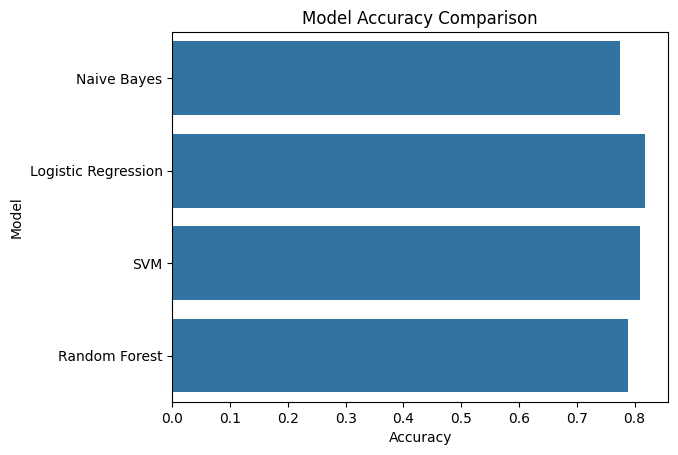

In [39]:
sns.barplot(

    x="Accuracy",

    y="Model",

    data=results

)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

Rating Function

In [40]:
import random

In [41]:
def generate_rating(sentiment):

    if sentiment == "Positive":

        return random.randint(8,10)

    elif sentiment == "Neutral":

        return random.randint(4,7)

    else:

        return random.randint(1,3)

In [42]:
#here we use clean text before prediciting the final
import re
import nltk

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

In [43]:
stop_words = set(
    stopwords.words("english")
)

important_negations = {
    "not",
    "no",
    "nor",
    "never"
}

stop_words = stop_words - important_negations

lemmatizer = WordNetLemmatizer()

In [44]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", " ", text)

    # remove html tags
    text = re.sub(r"<.*?>", " ", text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)

    # remove punctuation
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # tokenize
    words = text.split()

    # stopword removal + lemmatization
    words = [

        lemmatizer.lemmatize(word)

        for word in words

        if word not in stop_words
        and len(word) > 2
    ]

    return " ".join(words)

In [45]:
#create prediction function
def predict_sentiment(review):

    # preprocess
    cleaned = clean_text(review)

    # vectorize
    vectorized = tfidf.transform(
        [cleaned]
    )

    # predict
    prediction = svm_model.predict(
        vectorized
    )[0]

    # decode label
    sentiment = label_encoder.inverse_transform(
        [prediction]
    )[0]

    # generate rating
    rating = generate_rating(
        sentiment
    )

    return sentiment, rating

In [46]:
predict_sentiment(

    "The movie story is not good but his visual is excellent"

)

('Positive', 9)

In [47]:
import joblib

In [48]:
joblib.dump(

    svm_model,

    "../models/sentiment_model.pkl"
)

['../models/sentiment_model.pkl']

In [49]:
joblib.dump(

    tfidf,

    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']

In [50]:
joblib.dump(

    label_encoder,

    "../models/label_encoder.pkl"
)

['../models/label_encoder.pkl']

In [51]:
loaded_model = joblib.load(
    "../models/sentiment_model.pkl"
)